# P. putida Fitness — Three-Source Transfer Learning & 72-Experiment Round-1 Recommendations

This notebook fits transfer learning models using **three taxonomically distinct source datasets**
and generates **72 Bayesian-optimised media compositions** per source for the first wet-lab round.

| Source dataset | Organisms | n |
|---|---|---|
| `pputida_source_putida.csv` | *P. putida* KT2440 only | 261 |
| `pputida_source_pseudomonas.csv` | All *Pseudomonas* spp. | 1,079 |
| `pputida_source_gammaproteobacteria.csv` | All Gammaproteobacteria | 1,494 |

**Candidate generation uses Sobol low-discrepancy sequences** (scrambled, power-of-2 size)
instead of random sampling, ensuring uniform coverage of the full 11-dimensional feature space.

**Search space** is loaded from `feature_config.json` (derived from `ingredients.json`):
biologist-defined physical min/max bounds, with pH restricted to {5, 7, 9}.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('always')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import torch
from torch import device
import random

from omicstl.simulation_utils.data_utils import DatasetContainer
from omicstl.simulation_utils.model_utils import (
    fit_dl_model, fit_rf_model, predict_dl_model, predict_rf_model
)
from omicstl.simulation_utils import (
    recommend_next_batch,
    plot_candidate_scores,
    plot_acquisition_landscape,
    plot_batch_coverage,
)
from omicstl.r_utils import set_seed

plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

N_TRAIN    = 130
N_ENSEMBLE = 18
N_TEST     = 50
DATA_DIR   = 'data/'

## 2. Load Data

In [3]:
# ── Target ─────────────────────────────────────────────────────────────────────
target_raw = pd.read_csv(DATA_DIR + 'pputida_target.csv')

ALL_CONDITIONS = [
    'd_glucose', 'sodium_citrate', 'sodium_octanoate', 'sodium_acetate',
    'sodium_benzoate', 'd_xylose', 'l_arabinose', 'sodium_chloride',
    'urea', 'ammonium_chloride', 'pH'
]

# ── Three source datasets ──────────────────────────────────────────────────────
SOURCE_FILES = {
    'P. putida only':          'pputida_source_putida.csv',
    'All Pseudomonas':         'pputida_source_pseudomonas.csv',
    'All Gammaproteobacteria': 'pputida_source_gammaproteobacteria.csv',
}

sources_raw = {
    label: pd.read_csv(DATA_DIR + fname)
    for label, fname in SOURCE_FILES.items()
}

print(f'Target  : {target_raw.shape[0]:>5} rows  |  response: "fitness"')
print()
for label, df in sources_raw.items():
    print(f'Source [{label:26s}]: {df.shape[0]:>5} rows')

# ── Feature config (from ingredients.json) ─────────────────────────────────────
with open(DATA_DIR + 'feature_config.json') as fh:
    cfg = json.load(fh)

feature_ranges = {col: tuple(v) for col, v in cfg['feature_ranges'].items()}
step_sizes     = cfg['step_sizes']   # {'pH': 2.0}
units          = cfg['units']

print(f'\nSearch space ({len(feature_ranges)} conditions from ingredients.json):')
print(f'  {"Condition":<22}  {"Min":>8}  {"Max":>8}  {"Step"}')
print('  ' + '-'*48)
for col in ALL_CONDITIONS:
    lo, hi = feature_ranges[col]
    step   = step_sizes.get(col, 'continuous')
    print(f'  {col:<22}  {lo:>8.3g}  {hi:>8.3g}  {step}')

Target  :   198 rows  |  response: "fitness"

Source [P. putida only            ]:   261 rows
Source [All Pseudomonas           ]:  1079 rows
Source [All Gammaproteobacteria   ]:  1494 rows

Search space (11 conditions from ingredients.json):
  Condition                    Min       Max  Step
  ------------------------------------------------
  d_glucose                      0         4  continuous
  sodium_citrate                 0         4  continuous
  sodium_octanoate               0         2  continuous
  sodium_acetate                 0        12  continuous
  sodium_benzoate                0       2.5  continuous
  d_xylose                       0         4  continuous
  l_arabinose                    0         4  continuous
  sodium_chloride                0       250  continuous
  urea                           0       0.5  continuous
  ammonium_chloride              0         1  continuous
  pH                             5         9  2.0


## 3. Target Split

The target (PpJE3959) is split once and **shared across all three source comparisons**
so that metrics are directly comparable.

In [4]:
tgt_df = target_raw[['fitness'] + ALL_CONDITIONS].rename(columns={'fitness': 'response'})

tgt_combo, tgt_test = train_test_split(
    tgt_df, train_size=N_TRAIN + N_ENSEMBLE, test_size=N_TEST, random_state=42)
tgt_train, tgt_ensemble = train_test_split(
    tgt_combo, train_size=N_TRAIN, test_size=N_ENSEMBLE, random_state=42)

print(f'Target split  —  train: {len(tgt_train)}  '
      f'ensemble: {len(tgt_ensemble)}  '
      f'test (held out): {len(tgt_test)}')
print(f'Target response  —  min: {tgt_df["response"].min():.4f}  '
      f'max: {tgt_df["response"].max():.4f}  '
      f'mean: {tgt_df["response"].mean():.4f}')

Target split  —  train: 130  ensemble: 18  test (held out): 50
Target response  —  min: -0.0018  max: 0.6111  mean: 0.1760


## 4. Hyperparameter Grid

In [5]:
param_grid = {
    'dropout':         [0.25, 0.5],
    'n_latent_dims':   [2],
    'hidden_dim_base': [6],
    'lr':              [0.01, 0.001],
    'source_epochs':   [1000],
    'target_epochs':   [1000],
    'freeze':          ['none'],
    'weight_decay':    [1e-4, 1e-2],
    'gamma':           [1, 2, 3]
}

## 5. Helper Functions

In [6]:
def predict_fn(info, X_df):
    """Unified predict wrapper for DL and RF models."""
    X = X_df[ALL_CONDITIONS]
    if info['type'] == 'dl':
        return np.array(predict_dl_model(info['model'], X), dtype=float).flatten()
    preds   = predict_rf_model(info['model'], X)
    pred_df = pd.DataFrame(preds)
    col     = 'pred_ensemble' if 'pred_ensemble' in pred_df.columns else pred_df.columns[-1]
    return pred_df[col].values.astype(float)


def fit_source(label, src_df):
    """
    Fit VAE, MLP, and RF for one source dataset against the shared target split.
    Also records the target_nosource (no-TL) RMSE from DL results for comparison.
    Returns a dict with per-model RMSE, test-set metrics, and the best model info.
    """
    print(f'\n{"="*60}')
    print(f'  Source: {label}  ({len(src_df):,} rows)')
    print(f'{"="*60}')

    datasets = DatasetContainer(
        source_data=src_df,
        target_data=tgt_train,
        target_ensemble_data=tgt_ensemble,
        target_test_data=[tgt_test]
    )
    datasets.set_response_column('response')

    # VAE
    random.seed(42); torch.manual_seed(42)
    vae_res, vae_model, _ = fit_dl_model(datasets, 'mult_vae', device('cpu'), param_grid)
    vae_row       = vae_res[vae_res['model_id'] == 'target']
    vae_rmse      = float(vae_row['rmse'].values[0]) if len(vae_row) else np.inf
    vae_notl_row  = vae_res[vae_res['model_id'] == 'target_nosource']
    vae_notl_rmse = float(vae_notl_row['rmse'].values[0]) if len(vae_notl_row) else np.nan
    print(f'  VAE  RMSE : {vae_rmse:.4f}  (no-TL: {vae_notl_rmse:.4f})')

    # MLP
    random.seed(42); torch.manual_seed(42)
    mlp_res, mlp_model, _ = fit_dl_model(datasets, 'mult_mlp', device('cpu'), param_grid)
    mlp_row       = mlp_res[mlp_res['model_id'] == 'target']
    mlp_rmse      = float(mlp_row['rmse'].values[0]) if len(mlp_row) else np.inf
    mlp_notl_row  = mlp_res[mlp_res['model_id'] == 'target_nosource']
    mlp_notl_rmse = float(mlp_notl_row['rmse'].values[0]) if len(mlp_notl_row) else np.nan
    print(f'  MLP  RMSE : {mlp_rmse:.4f}  (no-TL: {mlp_notl_rmse:.4f})')

    # RF
    random.seed(42); set_seed(42)
    rf_res, rf_model = fit_rf_model(datasets)
    rf_row   = rf_res[rf_res['model_type'] == 'pred_ensemble_full']
    rf_rmse  = float(rf_row['rmse'].values[0]) if len(rf_row) else np.inf
    print(f'  RF   RMSE : {rf_rmse:.4f}')

    # Best model
    registry = {
        'VAE': {'model': vae_model, 'type': 'dl', 'rmse': vae_rmse},
        'MLP': {'model': mlp_model, 'type': 'dl', 'rmse': mlp_rmse},
        'RF':  {'model': rf_model,  'type': 'rf', 'rmse': rf_rmse},
    }
    best_name = min(registry, key=lambda k: registry[k]['rmse'])
    best_info = {'model': registry[best_name]['model'],
                 'type':  registry[best_name]['type']}

    # Test-set metrics using the best model
    y_true = tgt_test['response'].values
    y_pred = predict_fn(best_info, tgt_test)
    rmse   = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae    = float(np.mean(np.abs(y_true - y_pred)))
    r, _   = pearsonr(y_true, y_pred)
    print(f'  Best: {best_name}  |  Test RMSE={rmse:.4f}  MAE={mae:.4f}  r={r:.4f}')

    return {
        'label':          label,
        'n_source':       len(src_df),
        'best_model':     best_name,
        'vae_rmse':       vae_rmse,
        'mlp_rmse':       mlp_rmse,
        'rf_rmse':        rf_rmse,
        'vae_notl_rmse':  vae_notl_rmse,
        'mlp_notl_rmse':  mlp_notl_rmse,
        'test_rmse':      rmse,
        'test_mae':       mae,
        'pearson_r':      r,
        'best_info':      best_info,
        'registry':       registry,
        'y_true':         y_true,
        'y_pred':         y_pred,
    }

## 6. Fit Models — All Three Sources

Each source is used in turn with the same target split and hyperparameter grid.
All three source CSVs use the same 11 conditions as the target (homogeneous transfer)
so `fc₁` weights transfer in all cases.

In [7]:
source_results = {}

for label, src_raw in sources_raw.items():
    src_df = src_raw[['Resp'] + ALL_CONDITIONS].rename(columns={'Resp': 'response'})
    source_results[label] = fit_source(label, src_df)

print('\nAll sources fitted.')


  Source: P. putida only  (261 rows)


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


  VAE  RMSE : 0.1252  (no-TL: 0.1291)


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


  MLP  RMSE : 0.0703  (no-TL: 0.1054)


...

/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


  VAE  RMSE : 0.1251  (no-TL: 0.1271)


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1088: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


  MLP  RMSE : 0.0732  (no-TL: 0.1277)
  RF   RMSE : 0.0585
  Best: RF  |  Test RMSE=0.0585  MAE=0.0480  r=0.8862

All sources fitted.


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1338: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1338: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)


In [ ]:
# ── No-transfer-learning (target-only) RF baseline ─────────────────────────────
# Trained on tgt_train ONLY (130 rows) — the exact same rows the TL RF uses in
# its update_models() step, so the comparison is apples-to-apples.
# tgt_ensemble (18 rows) is NOT included: the TL RF uses it only for ensemble
# weighting at prediction time, never as extra training data.
from sklearn.ensemble import RandomForestRegressor

rf_notl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_notl.fit(tgt_train[ALL_CONDITIONS], tgt_train['response'])

y_true_notl = tgt_test['response'].values
y_pred_notl = rf_notl.predict(tgt_test[ALL_CONDITIONS])
notl_rmse   = float(np.sqrt(np.mean((y_true_notl - y_pred_notl) ** 2)))
notl_mae    = float(np.mean(np.abs(y_true_notl - y_pred_notl)))
notl_r, _   = pearsonr(y_true_notl, y_pred_notl)

notl_result = {
    'test_rmse': notl_rmse,
    'test_mae':  notl_mae,
    'pearson_r': notl_r,
    'y_true':    y_true_notl,
    'y_pred':    y_pred_notl,
}
print(f'No-TL RF baseline  (n_train={len(tgt_train)}, target-only, same rows as TL update_models)')
print(f'  RMSE: {notl_rmse:.4f}  MAE: {notl_mae:.4f}  r: {notl_r:.4f}')

## 7. Metrics Summary

In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Source':             r['label'],
        'n source':           r['n_source'],
        'Best model':         r['best_model'],
        'VAE RMSE (TL)':      round(r['vae_rmse'],            4),
        'VAE RMSE (no-TL)':   round(r['vae_notl_rmse'],       4),
        'MLP RMSE (TL)':      round(r['mlp_rmse'],            4),
        'MLP RMSE (no-TL)':   round(r['mlp_notl_rmse'],       4),
        'RF RMSE (TL)':       round(r['rf_rmse'],             4),
        'RF RMSE (no-TL)':    round(notl_result['test_rmse'], 4),
        'Test RMSE (TL)':     round(r['test_rmse'],           4),
        'Test RMSE (no-TL)':  round(notl_result['test_rmse'], 4),
        'Test MAE (TL)':      round(r['test_mae'],            4),
        'Test MAE (no-TL)':   round(notl_result['test_mae'],  4),
        'Pearson r (TL)':     round(r['pearson_r'],           4),
        'Pearson r (no-TL)':  round(notl_result['pearson_r'], 4),
    }
    for r in source_results.values()
]).set_index('Source')

print('Transfer learning vs no-TL baseline — test set (n=50, shared split)')
print('RF no-TL: sklearn RF trained on tgt_train only (130 rows, same as TL update_models).')
print('DL no-TL: target_nosource row from each omicsTL run (same DL architecture, no source).\n')
display(
    summary.style
           .background_gradient(subset=['Test RMSE (TL)',  'Test RMSE (no-TL)'], cmap='RdYlGn_r')
           .background_gradient(subset=['Pearson r (TL)',  'Pearson r (no-TL)'], cmap='RdYlGn')
           .format({'n source': '{:,}'})
)

# ── Helper: compute MLP predictions on tgt_test ───────────────────────────────
def _mlp_preds(r):
    mlp_info = {'model': r['registry']['MLP']['model'], 'type': 'dl'}
    y_true   = tgt_test['response'].values
    y_pred   = predict_fn(mlp_info, tgt_test)
    rmse     = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    corr, _  = pearsonr(y_true, y_pred)
    return y_true, y_pred, rmse, corr

# ── Figure 1: MLP (with TL) predicted vs actual ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
fig.suptitle('Predicted vs Actual Fitness — MLP (with Transfer Learning)', fontweight='bold')

for ax, (label, r) in zip(axes, source_results.items()):
    y_true, y_pred, rmse_mlp, r_mlp = _mlp_preds(r)
    lim = [min(y_true.min(), y_pred.min()) - 0.02,
           max(y_true.max(), y_pred.max()) + 0.02]
    ax.scatter(y_true, y_pred, alpha=0.65, color='#ED7D31',
               edgecolors='white', linewidths=0.4, s=35)
    ax.plot(lim, lim, 'r--', lw=1.4)
    ax.set(xlabel='Actual fitness', title=label, xlim=lim, ylim=lim)
    ax.text(0.05, 0.95,
            f'r = {r_mlp:.3f}\nRMSE = {rmse_mlp:.3f}\n(MLP + TL)',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', ec='#ED7D31'))

axes[0].set_ylabel('Predicted fitness')
plt.tight_layout()
plt.show()

# ── Figure 2: Best model (RF, with TL) + no-TL baseline ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
fig.suptitle('Predicted vs Actual Fitness — Best Model (RF + TL) vs No-TL Baseline',
             fontweight='bold')

for ax, (label, r) in zip(axes[:3], source_results.items()):
    y_true, y_pred = r['y_true'], r['y_pred']
    lim = [min(y_true.min(), y_pred.min()) - 0.02,
           max(y_true.max(), y_pred.max()) + 0.02]
    ax.scatter(y_true, y_pred, alpha=0.65, color='steelblue',
               edgecolors='white', linewidths=0.4, s=35)
    ax.plot(lim, lim, 'r--', lw=1.4)
    ax.set(xlabel='Actual fitness', title=label, xlim=lim, ylim=lim)
    ax.text(0.05, 0.95,
            f'r = {r["pearson_r"]:.3f}\nRMSE = {r["test_rmse"]:.3f}\n({r["best_model"]} + TL)',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', ec='steelblue'))

ax = axes[3]
y_true_n, y_pred_n = notl_result['y_true'], notl_result['y_pred']
lim_n = [min(y_true_n.min(), y_pred_n.min()) - 0.02,
         max(y_true_n.max(), y_pred_n.max()) + 0.02]
ax.scatter(y_true_n, y_pred_n, alpha=0.65, color='darkorange',
           edgecolors='white', linewidths=0.4, s=35)
ax.plot(lim_n, lim_n, 'r--', lw=1.4)
ax.set(xlabel='Actual fitness',
       title='No Transfer Learning\n(target-only RF, 130 rows)',
       xlim=lim_n, ylim=lim_n)
ax.text(0.05, 0.95,
        f'r = {notl_result["pearson_r"]:.3f}\nRMSE = {notl_result["test_rmse"]:.3f}\n(RF, no source)',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='darkorange'))

axes[0].set_ylabel('Predicted fitness')
plt.tight_layout()
plt.show()

# ── RMSE bar chart — TL vs no-TL for each model family ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
fig.suptitle('RMSE: Transfer Learning vs No-TL Baseline', fontweight='bold')
model_colors = {'VAE': '#5B9BD5', 'MLP': '#ED7D31', 'RF': '#70AD47'}
notl_color   = '#C00000'
labels  = list(source_results.keys())
short   = ['Putida', 'Pseudomonas', 'Gamma']
x       = np.arange(len(short))
width   = 0.35

for ax, model in zip(axes, ['VAE', 'MLP', 'RF']):
    tl_rmses = [source_results[l][f'{model.lower()}_rmse'] for l in labels]
    if model in ('VAE', 'MLP'):
        notl_rmses = [source_results[l][f'{model.lower()}_notl_rmse'] for l in labels]
    else:
        notl_rmses = [notl_result['test_rmse']] * len(labels)

    bars_tl   = ax.bar(x - width/2, tl_rmses,   width, color=model_colors[model],
                       edgecolor='white', label='With TL')
    bars_notl = ax.bar(x + width/2, notl_rmses, width, color=notl_color,
                       alpha=0.70, edgecolor='white', label='No TL')

    ax.set(title=model, ylabel='Test RMSE', xticks=x, xticklabels=short)
    valid_notl = [v for v in notl_rmses if not (isinstance(v, float) and np.isnan(v))]
    ax.set_ylim(0, max(tl_rmses + valid_notl) * 1.35)
    ax.legend(fontsize=8)
    for bar, v in zip(bars_tl, tl_rmses):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                f'{v:.4f}', ha='center', fontsize=7.5)
    for bar, v in zip(bars_notl, notl_rmses):
        if not (isinstance(v, float) and np.isnan(v)):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                    f'{v:.4f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

## 8. Recommend 72 Experiments Per Source

For each source's best model, generate 72 Bayesian-optimised media compositions
for the first wet-lab round (72 slots per 96-well plate after controls).

**Candidate generation:** 8,192 Sobol points (2¹³, scrambled) — low-discrepancy,
space-filling coverage of the full 11-dimensional feasible space.

**Batch selection — top-EI shortlist + greedy max-min diversity:**
1. Score all 8,192 candidates with Expected Improvement
2. Shortlist the **top 10%** (≈820 candidates) by EI score — all genuinely high-quality
3. From the 820, greedily pick 72 that **maximise the minimum pairwise distance**
   (greedy 2-approximation of the NP-hard max-min problem)

This guarantees every selected point is in the top-EI tier **and** the 72 points
are as spread out as possible within that tier — strictly better than a distance
threshold because it actively optimises diversity rather than just preventing
the worst clustering.

**Constraints:** all values within `ingredients.json` bounds; pH ∈ {5, 7, 9}.

In [ ]:
recommendations = {}

for label, r in source_results.items():
    print(f'Recommending 72 experiments  [source: {label}]')
    batch, candidates = recommend_next_batch(
        model_info     = r['best_info'],
        existing_data  = tgt_combo,
        response_col   = 'response',
        feature_cols   = ALL_CONDITIONS,
        feature_ranges = feature_ranges,
        step_sizes     = step_sizes,        # pH ∈ {5, 7, 9}
        batch_size     = 72,
        acquisition    = 'EI',
        n_candidates   = 8192,             # 2^13 Sobol points
        n_mc_samples   = 50,
        shortlist_pct  = 0.05,             # top 5% EI  ~410 candidates
        return_candidates = True,
        seed           = 42,
    )
    recommendations[label] = {'batch': batch, 'candidates': candidates}

    k_shortlist = max(72, int(np.ceil(8192 * 0.05)))
    print(f'  Selected {len(batch)} experiments  |  '
          f'shortlist k={k_shortlist}  |  '
          f'best predicted fitness: {batch["predicted_mean"].max():.4f}  |  '
          f'model: {r["best_model"]}')

print('\nAll recommendations generated.')

## 9. Diagnostic Plots

### 9.1 Explore–Exploit Landscape
Predicted mean vs uncertainty for all 8,192 Sobol candidates (one panel per source).
Red stars = recommended batch.  High EI (warm colour) = high predicted mean **and** high uncertainty.

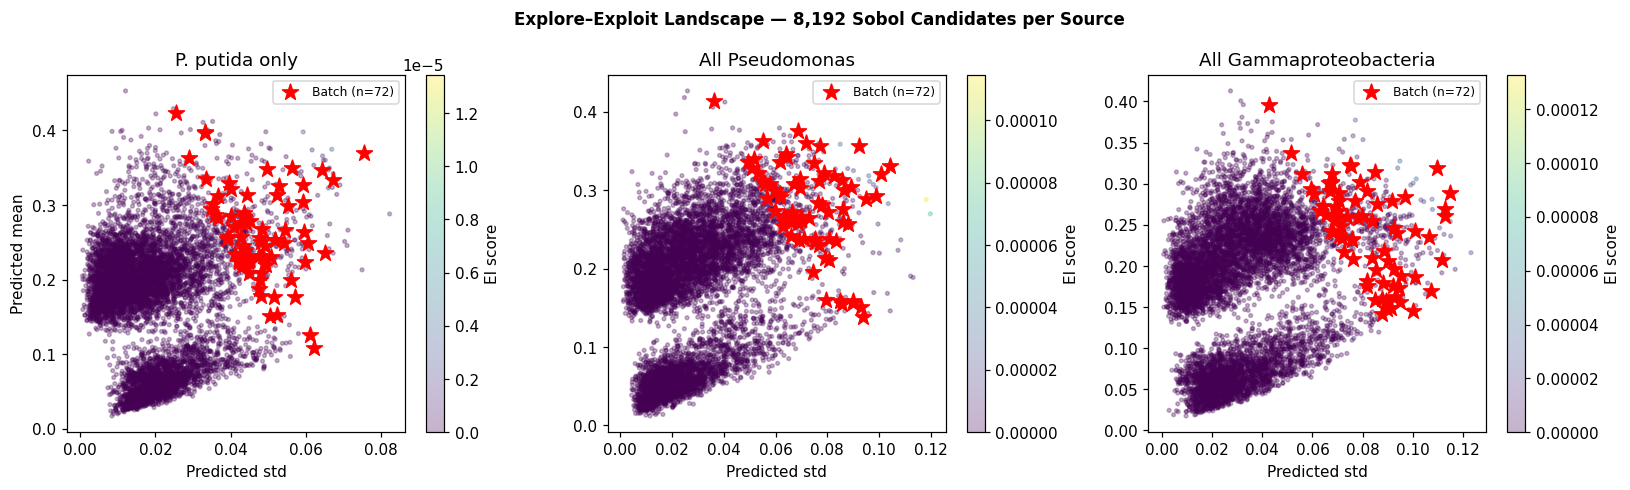

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Explore–Exploit Landscape — 8,192 Sobol Candidates per Source',
             fontsize=11, fontweight='bold')

for ax, (label, recs) in zip(axes, recommendations.items()):
    cands = recs['candidates']
    batch = recs['batch']
    sc = ax.scatter(
        cands['predicted_std'], cands['predicted_mean'],
        c=cands['acquisition_score'], cmap='viridis',
        alpha=0.3, s=6, rasterized=True
    )
    ax.scatter(batch['predicted_std'], batch['predicted_mean'],
               c='red', marker='*', s=120, zorder=6,
               label=f'Batch (n={len(batch)})')
    ax.set(xlabel='Predicted std', ylabel='Predicted mean' if ax == axes[0] else '',
           title=label)
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='EI score')

plt.tight_layout()
plt.show()

### 9.2 Batch Coverage — Parallel Coordinates
One plot per source.  Blue = existing target observations (shaded by fitness);
red = the 72 recommended compositions.

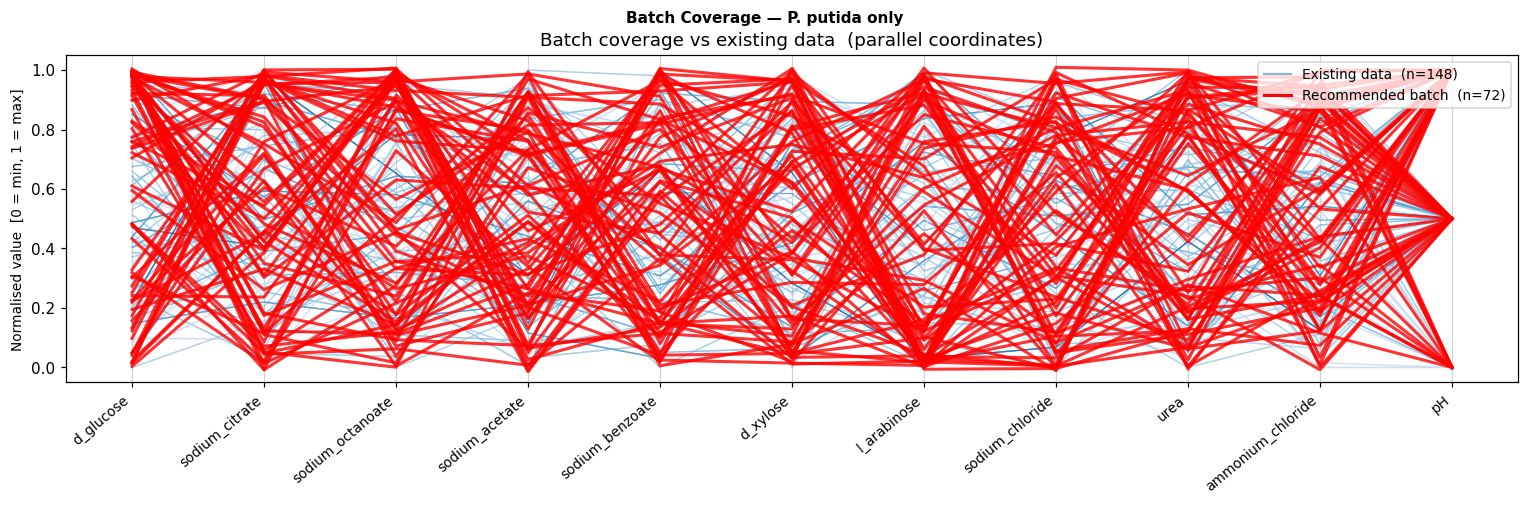

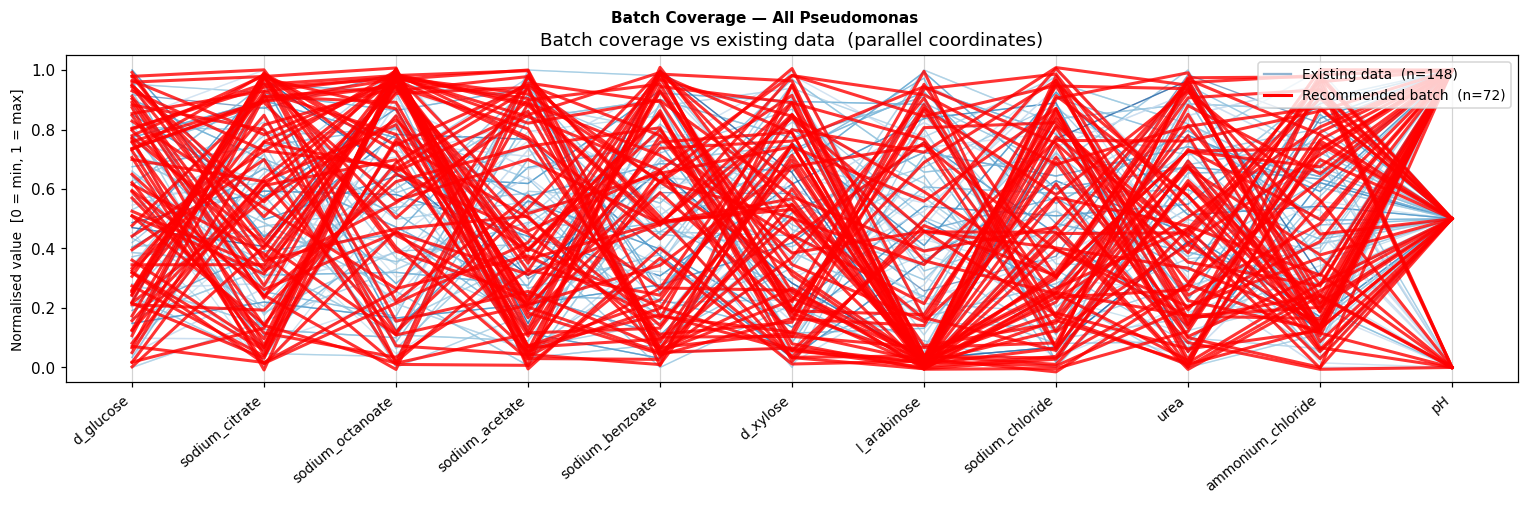

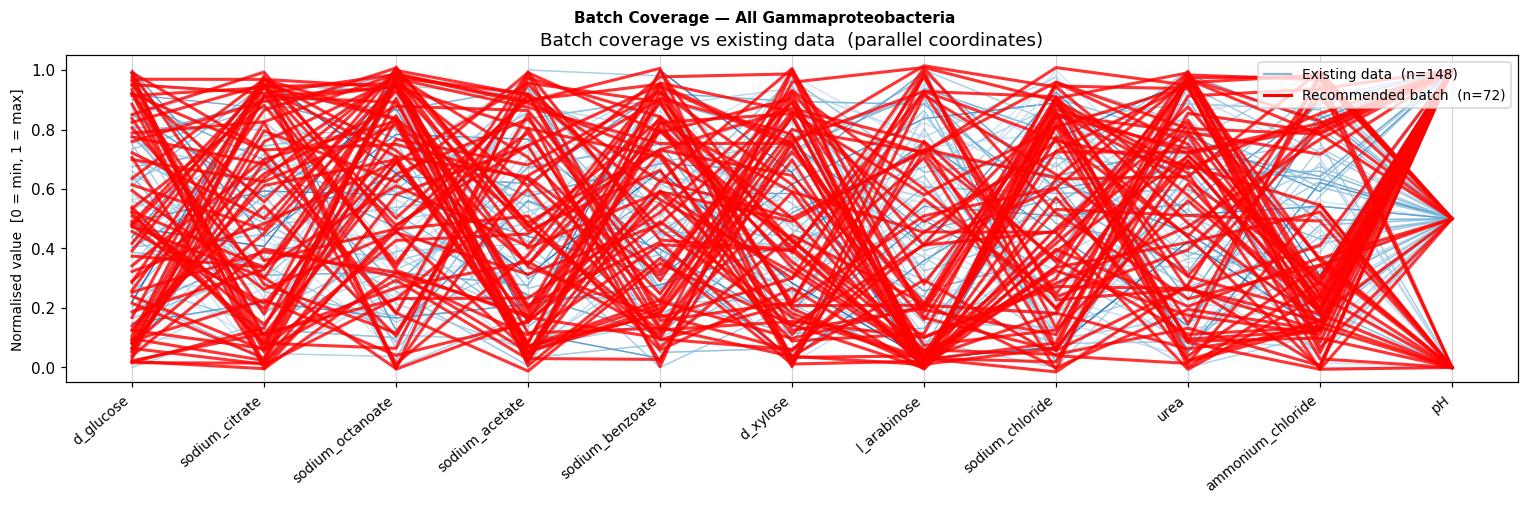

In [11]:
for label, recs in recommendations.items():
    fig = plot_batch_coverage(
        batch         = recs['batch'],
        existing_data = tgt_combo,
        feature_cols  = ALL_CONDITIONS,
        response_col  = 'response',
    )
    fig.suptitle(f'Batch Coverage — {label}', y=1.01, fontsize=10, fontweight='bold')
    plt.show()

### 9.3 Acquisition Landscape
2-D EI surface for the source with the lowest test RMSE.
Left: `d_glucose` vs `pH`; right: `sodium_octanoate` vs `ammonium_chloride`.

Plotting acquisition landscape for best source: All Gammaproteobacteria


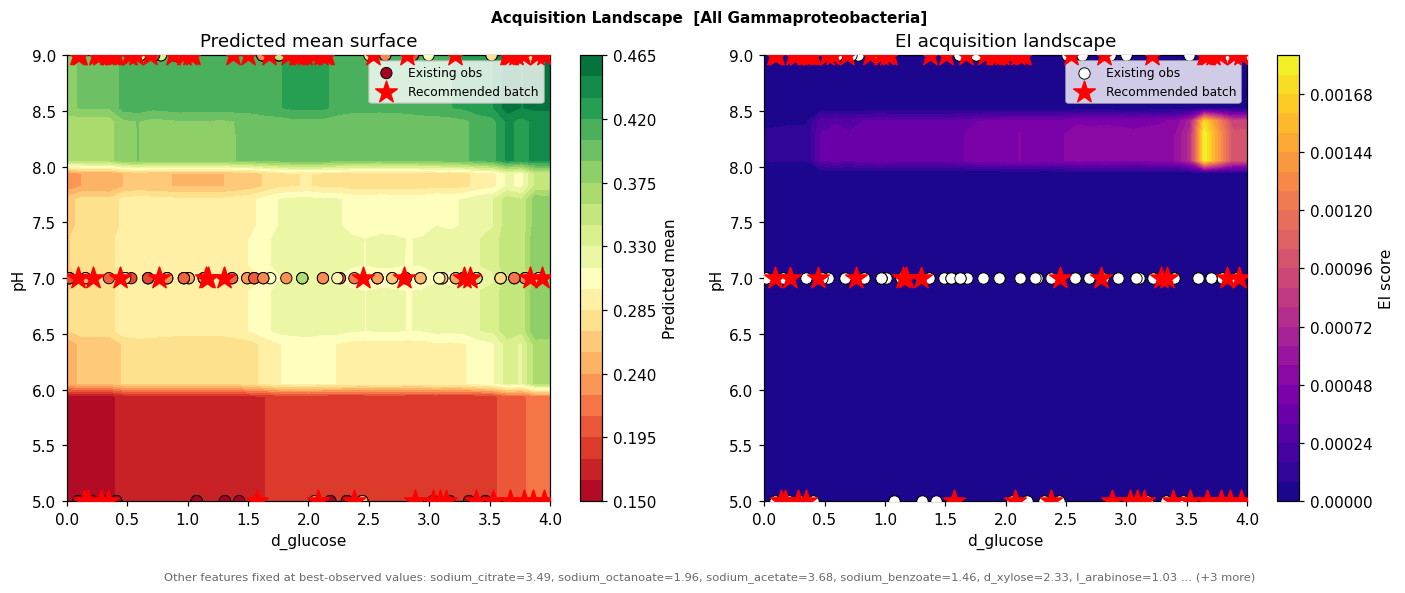

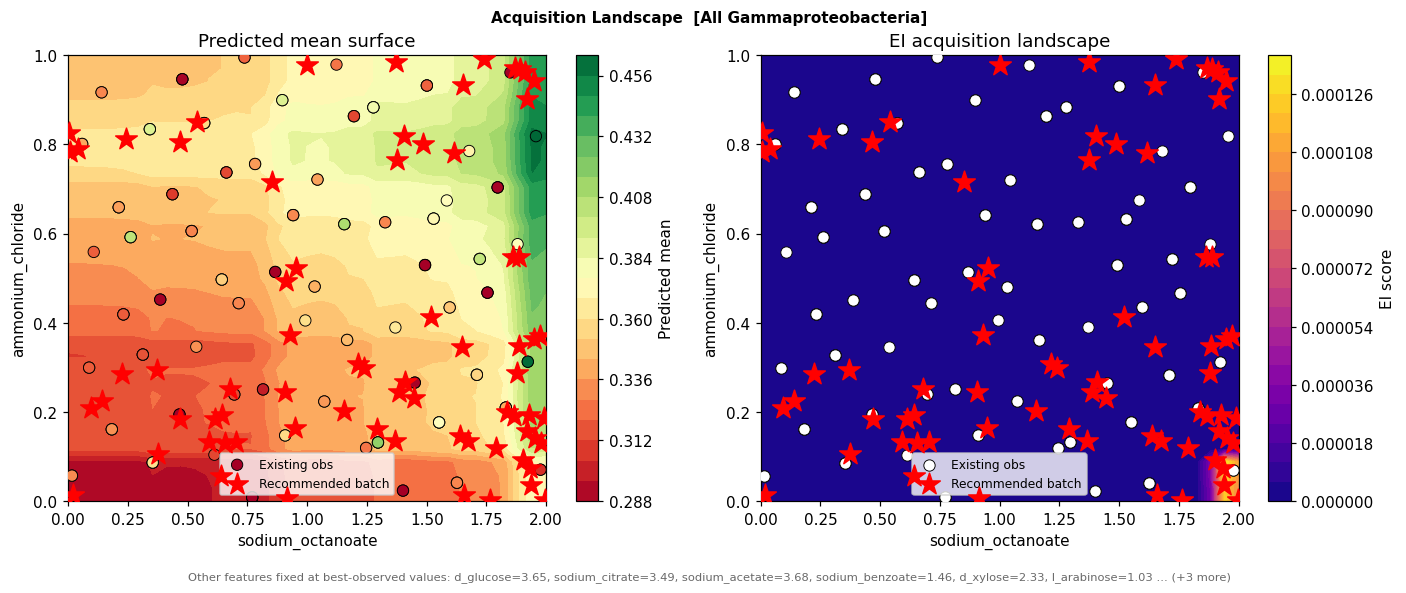

In [12]:
best_source = min(source_results, key=lambda k: source_results[k]['test_rmse'])
print(f'Plotting acquisition landscape for best source: {best_source}')

for x_col, y_col in [('d_glucose', 'pH'), ('sodium_octanoate', 'ammonium_chloride')]:
    fig = plot_acquisition_landscape(
        model_info     = source_results[best_source]['best_info'],
        existing_data  = tgt_combo,
        response_col   = 'response',
        feature_cols   = ALL_CONDITIONS,
        x_col          = x_col,
        y_col          = y_col,
        batch          = recommendations[best_source]['batch'],
        feature_ranges = feature_ranges,
        n_grid         = 35,
        acquisition    = 'EI',
        n_mc_samples   = 20,
    )
    fig.suptitle(f'Acquisition Landscape  [{best_source}]',
                 y=1.01, fontsize=10, fontweight='bold')
    plt.show()

## 10. Recommended Experiments

72 media compositions per source, ranked by EI acquisition score.
All values are within the bounds from `ingredients.json`; pH ∈ {5, 7, 9}.

In [13]:
DISPLAY_COLS = ALL_CONDITIONS + ['predicted_mean', 'predicted_std',
                                  'acquisition_score', 'batch_rank']

for label, recs in recommendations.items():
    rec = recs['batch'][DISPLAY_COLS].copy()
    for col in ALL_CONDITIONS:
        rec[col] = rec[col].round(4)
    for col in ['predicted_mean', 'predicted_std', 'acquisition_score']:
        rec[col] = rec[col].round(5)

    r = source_results[label]
    print(f'\n--- {label} ---')
    print(f'    Best model: {r["best_model"]}   '
          f'Test RMSE: {r["test_rmse"]:.4f}   '
          f'Pearson r: {r["pearson_r"]:.4f}')
    print(f'    Current best observed fitness: {tgt_combo["response"].max():.4f}')
    print(f'    Best predicted fitness (batch): {recs["batch"]["predicted_mean"].max():.4f}')
    display(
        rec.style
           .background_gradient(subset=['predicted_mean'], cmap='YlGn')
           .background_gradient(subset=['acquisition_score'], cmap='Oranges')
           .set_properties(**{'font-size': '10px'})
           .set_caption(label)
    )


--- P. putida only ---
    Best model: RF   Test RMSE: 0.0602   Pearson r: 0.8774
    Current best observed fitness: 0.6111
    Best predicted fitness (batch): 0.4228


,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,pH,predicted_mean,predicted_std,acquisition_score,batch_rank
0,0.886700,2.429700,0.814400,10.146900,0.492900,1.557600,0.036500,39.671600,0.261800,0.373700,9.000000,0.369070,0.075390,0.000010,1
1,1.281300,0.092100,0.439100,5.114000,2.436900,3.138500,0.097500,4.883600,0.105400,0.425800,9.000000,0.347360,0.064240,0.000000,2
2,0.793100,1.347700,0.295900,5.925000,0.269200,2.758000,0.111000,188.191000,0.403500,0.991100,9.000000,0.333100,0.067360,0.000000,3
3,1.216200,2.888900,0.190600,10.926400,2.301100,3.817400,0.088400,29.406700,0.391300,0.132900,9.000000,0.349200,0.056370,0.000000,4
4,3.636200,0.557000,1.707500,9.560600,0.941200,1.446900,0.493300,249.336600,0.498900,0.872700,9.000000,0.326130,0.059260,0.000000,5
5,3.803600,1.423600,0.486500,11.080900,1.108800,0.321500,1.066300,0.972400,0.485900,0.906400,9.000000,0.303490,0.059330,0.000000,6
6,0.976200,0.973400,1.654900,9.112800,0.068600,0.068700,0.051200,240.151000,0.001900,0.586800,9.000000,0.348040,0.049570,0.000000,7
7,3.997700,2.950700,0.156500,2.327700,2.441100,0.187500,0.411800,147.608000,0.493500,0.040800,9.000000,0.324910,0.052890,0.000000,8
8,3.912500,3.369300,0.666000,3.830700,1.677000,1.676000,3.813500,112.182500,0.477900,0.129600,7.000000,0.298120,0.055340,0.000000,9
9,3.821700,3.908600,1.989800,1.682200,2.396300,3.362000,2.338100,77.392700,0.452800,0.929600,7.000000,0.313540,0.052410,0.000000,10



--- All Pseudomonas ---
    Best model: RF   Test RMSE: 0.0592   Pearson r: 0.8830
    Current best observed fitness: 0.6111
    Best predicted fitness (batch): 0.4134


,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,pH,predicted_mean,predicted_std,acquisition_score,batch_rank
0,1.449400,0.306100,1.903800,2.788800,2.303500,1.383700,0.630100,143.062400,0.239400,0.314700,9.000000,0.330410,0.104370,0.000110,1
1,1.022400,3.264600,1.862000,3.989100,2.414100,1.011200,0.030900,42.250600,0.012200,0.287200,7.000000,0.356350,0.092230,0.000080,2
2,0.442000,3.876900,1.000500,10.749100,2.357700,0.797700,0.034900,109.507900,0.478100,0.977700,7.000000,0.320180,0.100830,0.000060,3
3,3.107800,3.921600,0.320600,3.181500,0.171900,0.473700,0.105800,236.265300,0.289300,0.144500,9.000000,0.292680,0.098630,0.000020,4
4,2.925200,3.936300,1.433700,0.605800,0.663900,3.535500,0.115600,175.798600,0.070600,0.763100,9.000000,0.356620,0.077020,0.000010,5
5,1.908700,3.636500,1.867000,9.610900,0.172300,1.776200,0.864400,234.051000,0.468000,0.191800,9.000000,0.288700,0.095120,0.000010,6
6,0.875100,0.160900,1.926700,10.985700,1.550900,3.997900,0.679500,17.564800,0.347600,0.194200,9.000000,0.303590,0.089310,0.000010,7
7,3.844200,3.135700,1.914200,11.936500,0.431300,0.482600,3.691300,243.814800,0.210900,0.714100,9.000000,0.313290,0.085630,0.000010,8
8,0.511000,3.910800,0.782200,2.998600,2.138400,0.232400,0.091200,57.101600,0.407000,0.282900,9.000000,0.375370,0.068590,0.000010,9
9,0.217000,3.041100,1.917800,0.239900,0.913400,0.056700,0.107900,192.519300,0.222600,0.901800,7.000000,0.359590,0.071690,0.000000,10



--- All Gammaproteobacteria ---
    Best model: RF   Test RMSE: 0.0585   Pearson r: 0.8862
    Current best observed fitness: 0.6111
    Best predicted fitness (batch): 0.3951


,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,pH,predicted_mean,predicted_std,acquisition_score,batch_rank
0,3.211100,1.222200,1.900900,7.327300,2.418600,3.926500,0.101700,200.481600,0.472100,0.092700,9.000000,0.319460,0.109670,0.000130,1
1,2.101100,1.366200,1.674600,1.020400,0.565600,3.182400,2.858400,249.114800,0.473700,0.134200,9.000000,0.288800,0.114930,0.000090,2
2,0.969100,0.269700,0.590600,0.499700,1.472000,1.197600,3.851200,59.083400,0.134600,0.131900,9.000000,0.268650,0.112880,0.000040,3
3,1.940200,3.807900,0.655800,2.155600,0.251900,3.044200,3.661500,190.276500,0.051800,0.130500,9.000000,0.260740,0.112740,0.000030,4
4,2.035700,0.609300,1.365900,11.420700,2.211400,0.884500,3.924200,19.293400,0.309800,0.134900,9.000000,0.283880,0.096810,0.000010,5
5,1.373600,2.807400,1.638800,0.375700,2.039600,3.397400,2.296300,200.505100,0.014100,0.146000,9.000000,0.235780,0.106470,0.000010,6
6,0.217000,3.041100,1.917800,0.239900,0.913400,0.056700,0.107900,192.519300,0.222600,0.901800,7.000000,0.314340,0.084730,0.000000,7
7,3.029200,3.578400,1.867900,5.566000,1.644400,0.146200,0.176700,76.508300,0.486100,0.972300,5.000000,0.207020,0.111540,0.000000,8
8,1.020600,1.576100,0.642700,0.792700,0.463200,3.109800,0.314000,34.323200,0.281700,0.192200,9.000000,0.278440,0.091580,0.000000,9
9,2.137300,3.528000,0.703000,10.998300,0.457200,2.886000,0.868900,3.433800,0.101400,0.132000,9.000000,0.242330,0.100690,0.000000,10


## 11. Export Recommendations

One CSV per source.  The biologist receives three files — one per taxonomic source —
each containing 72 rows ready for plate layout.

In [14]:
slug_map = {
    'P. putida only':          'putida',
    'All Pseudomonas':         'pseudomonas',
    'All Gammaproteobacteria': 'gammaproteobacteria',
}

for label, recs in recommendations.items():
    slug     = slug_map[label]
    out_path = DATA_DIR + f'recommendations_round1_{slug}.csv'
    out_cols = ALL_CONDITIONS + ['predicted_mean', 'predicted_std',
                                  'acquisition_score', 'batch_rank']
    recs['batch'][out_cols].to_csv(out_path, index=False)
    print(f'Saved  {out_path}  ({len(recs["batch"])} experiments)')

print('\nRound-1 recommendations ready.')

Saved  data/recommendations_round1_putida.csv  (72 experiments)
Saved  data/recommendations_round1_pseudomonas.csv  (72 experiments)
Saved  data/recommendations_round1_gammaproteobacteria.csv  (72 experiments)

Round-1 recommendations ready.


## 12. Round-2 Template

After the 72 experiments are run and fitness values measured, append the results
to `existing_data` and re-run `recommend_next_batch`.  The model can be retrained
or used as-is (the acquisition function will automatically account for new data).

In [ ]:
# Template — fill in measured_fitness (list of 72 values) after the wet-lab run
#
# source_label   = 'P. putida only'   # or whichever source to use for round 2
# round1_results = recommendations[source_label]['batch'][ALL_CONDITIONS].copy()
# round1_results['response'] = measured_fitness
#
# existing_r2 = pd.concat([tgt_combo, round1_results], ignore_index=True)
#
# batch_r2, cands_r2 = recommend_next_batch(
#     model_info     = source_results[source_label]['best_info'],
#     existing_data  = existing_r2,
#     response_col   = 'response',
#     feature_cols   = ALL_CONDITIONS,
#     feature_ranges = feature_ranges,
#     step_sizes     = step_sizes,
#     batch_size     = 72,
#     acquisition    = 'EI',
#     n_candidates   = 8192,
#     return_candidates = True,
#     seed           = 43,   # increment seed each round
# )
print('Round-2 template ready.  Fill in measured_fitness to continue.')